# Understanding relative depth and progression

        ## Author

        [Rafael S. de Souza](https://rafaelsdesouza.com.br/)

        ## Learning goals

        - recover the circular reference case
- compare compact, elongated, folded, and perforated supports
- narrow a tail while keeping its centreline fixed
- identify how an internal boundary enters rho_D

        ## Keywords

        circular reference, elongated tail, folded support, internal boundary, coordinate interpretation

        ## Summary

        Use controlled supports to determine when relative boundary depth and normalized progression coincide and when they separate.

        ## Resources

        - [Documentation](https://rafaelsdesouza.com.br/multiradial/docs/)
        - [Source](https://github.com/RafaelSdeSouza/multiradial)
        - Paper/preprint: bibliographic link pending
        - [Citation metadata](https://github.com/RafaelSdeSouza/multiradial/blob/main/CITATION.cff)

        Execute this notebook from a local checkout. A Colab installation link
        will be added only after the first immutable release tag exists.

In [1]:
from pathlib import Path
import sys
source = Path("src") if Path("src/radialpaths").exists() else Path("../src")
if str(source.resolve()) not in sys.path:
    sys.path.insert(0, str(source.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from radialpaths import build_geometry, radial_profile

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11, "axes.linewidth": 0.8})

## Controlled support families

The supplied centre and support determine both coordinate
fields. The examples below change one geometric feature at a
time rather than changing the measured tracer.

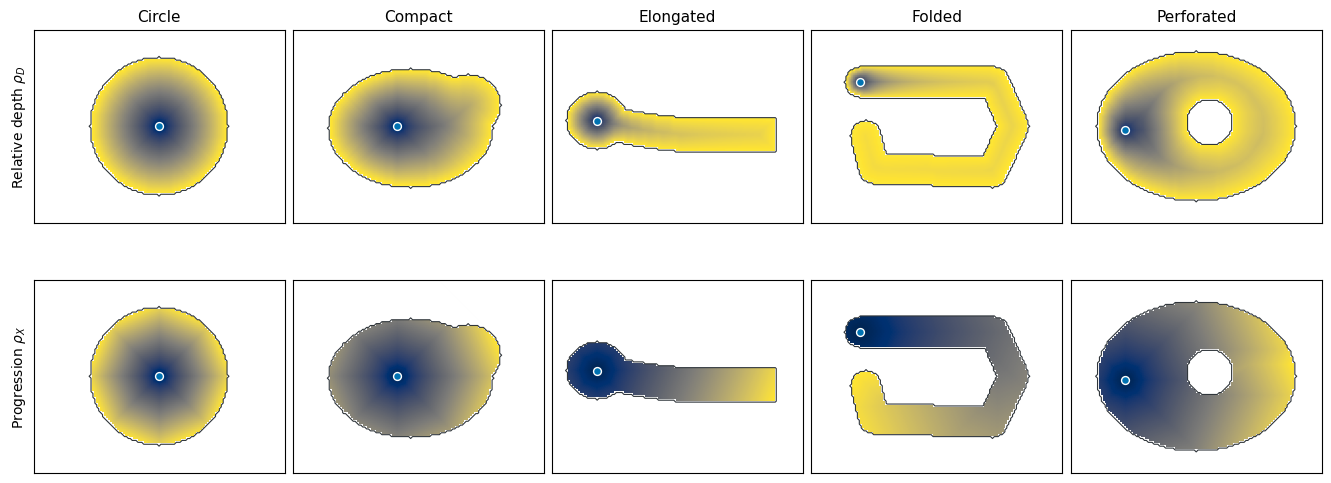

In [2]:
yy, xx = np.indices((101, 131), dtype=float)

def distance_to_polyline(x, y, points):
    result = np.full_like(x, np.inf, dtype=float)
    for (ax, ay), (bx, by) in zip(points[:-1], points[1:]):
        dx, dy = bx - ax, by - ay
        t = np.clip(((x - ax) * dx + (y - ay) * dy) / (dx * dx + dy * dy), 0, 1)
        result = np.minimum(result, np.hypot(x - (ax + t * dx), y - (ay + t * dy)))
    return result

def make_case(name, tail_half_width=9):
    if name == "circle":
        mask = np.hypot(xx - 65, yy - 50) <= 36
        centre = [(50, 65)]
    elif name == "compact":
        mask = ((xx - 61) / 43) ** 2 + ((yy - 51) / 31) ** 2 <= 1
        mask |= ((xx - 91) / 17) ** 2 + ((yy - 39) / 16) ** 2 <= 1
        centre = [(50, 54)]
    elif name == "elongated":
        spine_y = 47 + 0.10 * (xx - 23) + 3 * np.sin((xx - 23) / 24)
        mask = (xx >= 20) & (xx <= 116) & (np.abs(yy - spine_y) <= tail_half_width)
        mask |= ((xx - 23) / 16) ** 2 + ((yy - 47) / 15) ** 2 <= 1
        centre = [(47, 23)]
    elif name == "folded":
        path = [(25, 27), (95, 27), (105, 50), (94, 74), (32, 72), (28, 55)]
        mask = distance_to_polyline(xx, yy, path) <= 8
        centre = [(27, 25)]
    elif name == "perforated":
        mask = ((xx - 65) / 52) ** 2 + ((yy - 50) / 39) ** 2 <= 1
        mask &= (xx - 72) ** 2 + (yy - 48) ** 2 >= 12**2
        centre = [(52, 28)]
    mask[[0, -1], :] = False
    mask[:, [0, -1]] = False
    return mask, centre, build_geometry(mask, centre)

cases = {name: make_case(name) for name in ("circle", "compact", "elongated", "folded", "perforated")}

fig, axes = plt.subplots(2, 5, figsize=(13.2, 5.0), constrained_layout=True)
for column, (name, (mask, centre, geometry)) in enumerate(cases.items()):
    for row, field in enumerate((geometry.rho_D, geometry.rho_X)):
        axes[row, column].imshow(field, cmap="cividis", origin="upper", vmin=0, vmax=1)
        axes[row, column].contour(mask, [0.5], colors="#30363b", linewidths=0.8)
        axes[row, column].scatter([centre[0][1]], [centre[0][0]], c="#0072B2", edgecolors="white", s=32)
        axes[row, column].set(xticks=[], yticks=[])
    axes[0, column].set_title(name.capitalize())
axes[0, 0].set_ylabel(r"Relative depth $\rho_D$")
axes[1, 0].set_ylabel(r"Progression $\rho_X$")
plt.show()

The centred circle supplies the finite-grid reference: both
fields approximate conventional normalized radius. Compact
perturbations preserve much of that agreement. Elongation,
folding, and an internal excluded region separate the two
denominators.

## Narrow the tail without moving its centreline

The sampled centreline and supplied centre remain fixed. Only
the lateral half-width changes.

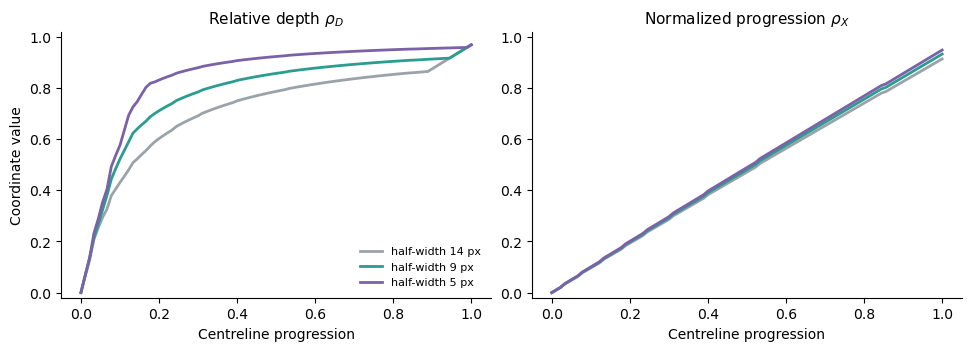

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), constrained_layout=True)
for half_width, colour in zip((14, 9, 5), ("#9aa3aa", "#2A9D8F", "#7B61A8")):
    mask, centre, geometry = make_case("elongated", tail_half_width=half_width)
    columns = np.arange(23, 114)
    rows = np.rint(47 + 0.10 * (columns - 23) + 3 * np.sin((columns - 23) / 24)).astype(int)
    progression = (columns - columns.min()) / (columns.max() - columns.min())
    axes[0].plot(progression, geometry.rho_D[rows, columns], color=colour, lw=2, label=f"half-width {half_width} px")
    axes[1].plot(progression, geometry.rho_X[rows, columns], color=colour, lw=2)
axes[0].set(title=r"Relative depth $\rho_D$", ylabel="Coordinate value")
axes[1].set(title=r"Normalized progression $\rho_X$")
for ax in axes:
    ax.set(xlabel="Centreline progression", ylim=(-0.02, 1.02))
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
plt.show()

Narrowing the support reduces the centreline values of
$\rho_D=d/(d+b)$ because the nearby lateral boundary reduces
$b$. The ordering of $\rho_X=d/L$ remains tied to distance from
the supplied centre relative to the full region extent. In the
perforated case, excluded hole pixels cannot be traversed and
adjacent in-support pixels enter the boundary set used for $b$.